# 03 — Audio Classification

Dans ce notebook, nous allons construire un premier système complet de classification audio.

L’objectif est de comprendre comment passer d’un signal audio brut à une classe prédite.

Nous allons suivre ce pipeline :

```text
Audio
→ extraction des MFCC
→ création d’un vecteur de caractéristiques
→ entraînement d’un modèle k-NN
→ prédiction
→ évaluation

## Objectifs du notebook

À la fin de ce notebook, nous saurons :

- générer un petit dataset audio synthétique ;
- associer un label à chaque signal ;
- extraire des coefficients MFCC ;
- transformer un audio de longueur variable en vecteur fixe ;
- séparer les données en train et test ;
- entraîner un classifieur k-NN ;
- calculer l’accuracy ;
- analyser une matrice de confusion ;
- tester le modèle sur un nouvel audio.

In [38]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display
from sklearn.metrics import classification_report


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Chargement des métadonnées ESC-50

ESC-50 contient 2 000 extraits audio répartis entre 50 classes.

Le fichier `esc50.csv` associe chaque fichier audio à plusieurs informations, notamment :

- son nom de fichier ;
- son fold ;
- son identifiant de classe ;
- le nom de sa catégorie ;
- sa source d’origine.

Nous allons commencer par charger ces métadonnées afin d’explorer le dataset.

In [11]:
dataset_path = Path("data/ESC-50")
metadata_path = dataset_path / "meta" / "esc50.csv"
audio_directory = dataset_path / "audio"

print("Dataset trouvé :", dataset_path.exists())
print("Métadonnées trouvées :", metadata_path.exists())
print("Dossier audio trouvé :", audio_directory.exists())

Dataset trouvé : True
Métadonnées trouvées : True
Dossier audio trouvé : True


In [12]:
metadata = pd.read_csv(metadata_path)

print("Shape des métadonnées :", metadata.shape)
print("Colonnes :", metadata.columns.tolist())

metadata.head()

Shape des métadonnées : (2000, 7)
Colonnes : ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 2. Exploration des classes

Nous allons maintenant vérifier :

- le nombre total de classes ;
- le nombre d’exemples par classe ;
- quelques catégories disponibles dans ESC-50.

Cela nous permettra de choisir un sous-ensemble équilibré pour notre premier modèle.

In [13]:
print("Nombre de classes :", metadata["category"].nunique())

class_counts = metadata["category"].value_counts()

print("\nNombre d'exemples par classe :")
print(class_counts.head(10))

print("\nQuelques catégories :")
print(sorted(metadata["category"].unique())[:20])

Nombre de classes : 50

Nombre d'exemples par classe :
category
dog                 40
glass_breaking      40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
Name: count, dtype: int64

Quelques catégories :
['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks']


## 3. Sélection d’un sous-ensemble de classes

Pour construire une première baseline claire et rapide, nous n’utiliserons pas immédiatement les 50 classes du dataset.

Nous sélectionnons cinq catégories acoustiquement différentes :

- `dog` ;
- `rain` ;
- `crying_baby` ;
- `clock_tick` ;
- `helicopter`.

Chaque classe contient 40 fichiers, soit 200 extraits audio au total.

In [15]:
selected_classes = [
    "dog",
    "rain",
    "crying_baby",
    "clock_tick",
    "helicopter"
]

subset = metadata[
    metadata["category"].isin(selected_classes)
].copy()

print("Shape du sous-ensemble :", subset.shape)
print("\nNombre d'exemples par classe :")
print(subset["category"].value_counts())

Shape du sous-ensemble : (200, 7)

Nombre d'exemples par classe :
category
dog            40
helicopter     40
rain           40
crying_baby    40
clock_tick     40
Name: count, dtype: int64


## 4. Vérification des folds

ESC-50 fournit cinq folds prédéfinis.

Chaque fold contient une partie des enregistrements de chaque classe.

Nous allons utiliser ces folds pour séparer les données sans mélanger arbitrairement les extraits.

In [16]:
fold_distribution = pd.crosstab(
    subset["category"],
    subset["fold"]
)

print(fold_distribution)

fold         1  2  3  4  5
category                  
clock_tick   8  8  8  8  8
crying_baby  8  8  8  8  8
dog          8  8  8  8  8
helicopter   8  8  8  8  8
rain         8  8  8  8  8


## 5. Construction des chemins audio

Le fichier de métadonnées contient uniquement le nom de chaque fichier.

Nous allons construire son chemin complet en combinant :

- le dossier `data/ESC-50/audio` ;
- la colonne `filename`.

Cela nous permettra ensuite de charger les signaux avec `librosa`.

In [17]:
subset["audio_path"] = subset["filename"].apply(
    lambda filename: audio_directory / filename
)

print(subset[["filename", "category", "fold", "audio_path"]].head())

print(
    "\nPremier fichier trouvé :",
    subset.iloc[0]["audio_path"].exists()
)

             filename    category  fold                           audio_path
0    1-100032-A-0.wav         dog     1   data/ESC-50/audio/1-100032-A-0.wav
14   1-110389-A-0.wav         dog     1   data/ESC-50/audio/1-110389-A-0.wav
55  1-172649-A-40.wav  helicopter     1  data/ESC-50/audio/1-172649-A-40.wav
56  1-172649-B-40.wav  helicopter     1  data/ESC-50/audio/1-172649-B-40.wav
57  1-172649-C-40.wav  helicopter     1  data/ESC-50/audio/1-172649-C-40.wav

Premier fichier trouvé : True


## 6. Chargement d’un premier fichier audio

Nous allons charger un premier extrait du sous-ensemble afin de vérifier :

- sa catégorie ;
- son sample rate ;
- sa durée ;
- sa forme ;
- ses valeurs minimale et maximale.

ESC-50 contient des fichiers de 5 secondes enregistrés à 44,1 kHz.

In [18]:
example_row = subset.iloc[0]

example_audio, example_sample_rate = librosa.load(
    example_row["audio_path"],
    sr=None,
    mono=True
)

example_duration = len(example_audio) / example_sample_rate

print("Catégorie :", example_row["category"])
print("Fichier :", example_row["filename"])
print("Sample rate :", example_sample_rate, "Hz")
print("Shape :", example_audio.shape)
print(f"Durée : {example_duration:.2f} secondes")
print("Valeur minimale :", example_audio.min())
print("Valeur maximale :", example_audio.max())

Catégorie : dog
Fichier : 1-100032-A-0.wav
Sample rate : 44100 Hz
Shape : (220500,)
Durée : 5.00 secondes
Valeur minimale : -0.9683838
Valeur maximale : 0.99884033


## 7. Visualisation et écoute d’un exemple

Avant d’extraire les caractéristiques, nous allons inspecter un fichier audio réel.

La waveform montre l’évolution de l’amplitude au cours du temps, mais elle ne montre pas directement les fréquences présentes dans le signal.

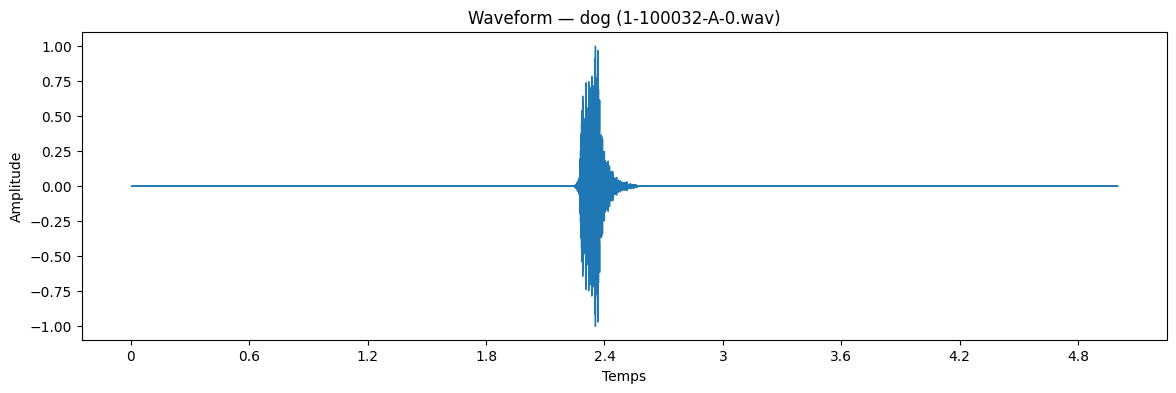

In [22]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    example_audio,
    sr=example_sample_rate
)

plt.title(
    f"Waveform — {example_row['category']} "
    f"({example_row['filename']})"
)
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.show()

In [23]:
display(
    Audio(
        example_audio,
        rate=example_sample_rate
    )
)

## 8. Rééchantillonnage à 16 kHz

Les fichiers ESC-50 sont enregistrés à 44,1 kHz.

Pour standardiser le prétraitement et rester cohérents avec les notebooks précédents, nous allons les convertir à 16 kHz avant d’extraire les MFCC.

Cette fréquence est couramment utilisée dans les systèmes de traitement de la parole et réduit aussi le coût de calcul.

In [24]:
target_sample_rate = 16000

example_audio_16k = librosa.resample(
    example_audio,
    orig_sr=example_sample_rate,
    target_sr=target_sample_rate
)

print("Sample rate original :", example_sample_rate, "Hz")
print("Sample rate cible :", target_sample_rate, "Hz")
print("Échantillons avant :", len(example_audio))
print("Échantillons après :", len(example_audio_16k))
print(
    "Durée après :",
    len(example_audio_16k) / target_sample_rate,
    "secondes"
)

Sample rate original : 44100 Hz
Sample rate cible : 16000 Hz
Échantillons avant : 220500
Échantillons après : 80000
Durée après : 5.0 secondes


## 9. Extraction des MFCC

Les MFCC sont une représentation compacte du contenu spectral d’un signal audio.

Ils sont calculés à partir d’une représentation Mel, puis compressés pour conserver les informations acoustiques les plus importantes.

Nous allons extraire 13 coefficients MFCC pour chaque frame temporelle.

Le résultat aura deux dimensions :

- les coefficients MFCC ;
- les positions temporelles.

In [25]:
n_mfcc = 13

example_mfcc = librosa.feature.mfcc(
    y=example_audio_16k,
    sr=target_sample_rate,
    n_mfcc=n_mfcc
)

print("Shape des MFCC :", example_mfcc.shape)
print("Nombre de coefficients :", example_mfcc.shape[0])
print("Nombre de frames :", example_mfcc.shape[1])

Shape des MFCC : (13, 157)
Nombre de coefficients : 13
Nombre de frames : 157


## 10. Visualisation des MFCC

Les MFCC évoluent au cours du temps.

Chaque ligne représente un coefficient différent et chaque colonne représente une frame temporelle.

Cette visualisation permet d’observer la structure acoustique compacte du son.

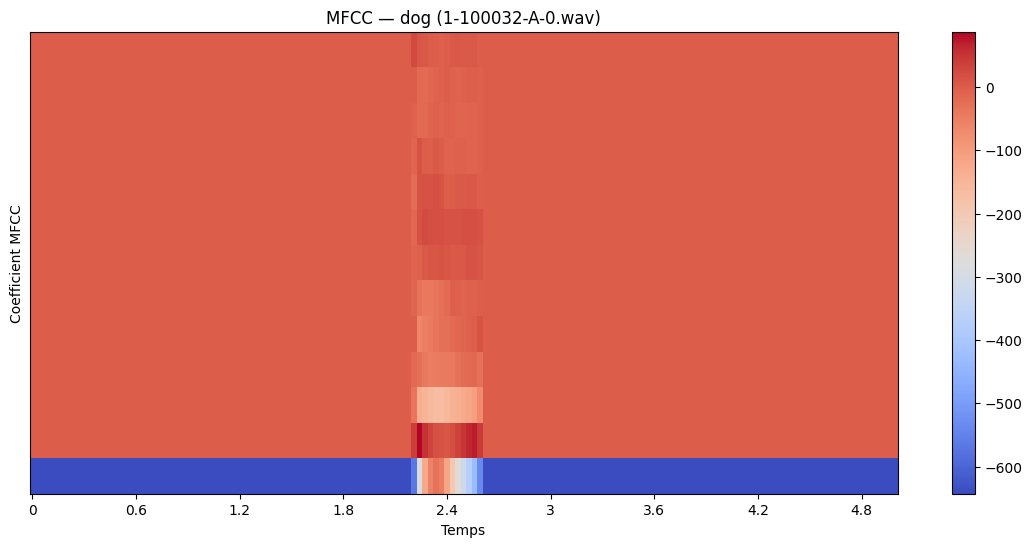

In [26]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    example_mfcc,
    sr=target_sample_rate,
    x_axis="time"
)

plt.colorbar()
plt.title(
    f"MFCC — {example_row['category']} "
    f"({example_row['filename']})"
)
plt.xlabel("Temps")
plt.ylabel("Coefficient MFCC")
plt.show()

## 11. Création d’un vecteur de caractéristiques fixe

Les MFCC ont une dimension temporelle.

Pour entraîner un modèle classique, nous devons convertir chaque audio en un vecteur de taille fixe.

Nous calculons donc, pour chacun des 13 coefficients :

- la moyenne dans le temps ;
- l’écart-type dans le temps.

Chaque fichier audio sera ainsi représenté par 26 valeurs.

In [27]:
mfcc_mean = example_mfcc.mean(axis=1)
mfcc_std = example_mfcc.std(axis=1)

example_features = np.concatenate([
    mfcc_mean,
    mfcc_std
])

print("Shape des moyennes :", mfcc_mean.shape)
print("Shape des écarts-types :", mfcc_std.shape)
print("Shape du vecteur final :", example_features.shape)

Shape des moyennes : (13,)
Shape des écarts-types : (13,)
Shape du vecteur final : (26,)


## 12. Fonction d’extraction des caractéristiques

Nous allons regrouper le prétraitement dans une fonction réutilisable.

Pour chaque fichier audio, la fonction :

1. charge le signal en mono ;
2. le rééchantillonne à 16 kHz ;
3. extrait 13 coefficients MFCC ;
4. calcule la moyenne et l’écart-type de chaque coefficient ;
5. retourne un vecteur fixe de 26 caractéristiques.

In [28]:
def extract_mfcc_features(
    audio_path,
    target_sample_rate=16000,
    n_mfcc=13
):
    audio, _ = librosa.load(
        audio_path,
        sr=target_sample_rate,
        mono=True
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=target_sample_rate,
        n_mfcc=n_mfcc
    )

    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    features = np.concatenate([
        mfcc_mean,
        mfcc_std
    ])

    return features.astype(np.float32)

In [29]:
test_features = extract_mfcc_features(
    example_row["audio_path"]
)

print("Shape :", test_features.shape)
print("Type :", test_features.dtype)
print("Valeurs finies :", np.isfinite(test_features).all())

Shape : (26,)
Type : float32
Valeurs finies : True


## 13. Extraction des caractéristiques du dataset

Nous allons maintenant appliquer la fonction d’extraction à tous les fichiers du sous-ensemble.

Pour chaque audio, nous stockerons :

- un vecteur de 26 caractéristiques MFCC ;
- son label ;
- son fold d’origine.

Cette étape transforme notre dataset audio en un dataset numérique utilisable par un modèle de machine learning.

In [30]:
features_list = []
labels_list = []
folds_list = []

for _, row in subset.iterrows():
    features = extract_mfcc_features(
        row["audio_path"]
    )

    features_list.append(features)
    labels_list.append(row["category"])
    folds_list.append(row["fold"])

X = np.array(features_list)
y = np.array(labels_list)
folds = np.array(folds_list)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)
print("Shape des folds :", folds.shape)
print("Valeurs finies :", np.isfinite(X).all())

Shape de X : (200, 26)
Shape de y : (200,)
Shape des folds : (200,)
Valeurs finies : True


## 14. Séparation des données avec les folds ESC-50

ESC-50 fournit cinq folds prédéfinis.

Nous utilisons ici :

- les folds 1 à 4 pour entraîner le modèle ;
- le fold 5 pour évaluer le modèle.

Cette méthode évite de créer une séparation aléatoire différente à chaque exécution.

In [32]:
train_mask = folds != 5
test_mask = folds == 5

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Shape de X_train :", X_train.shape)
print("Shape de X_test :", X_test.shape)
print("Shape de y_train :", y_train.shape)
print("Shape de y_test :", y_test.shape)

print("\nRépartition train :")
print(pd.Series(y_train).value_counts())

print("\nRépartition test :")
print(pd.Series(y_test).value_counts())

Shape de X_train : (160, 26)
Shape de X_test : (40, 26)
Shape de y_train : (160,)
Shape de y_test : (40,)

Répartition train :
dog            32
helicopter     32
rain           32
crying_baby    32
clock_tick     32
Name: count, dtype: int64

Répartition test :
crying_baby    8
helicopter     8
rain           8
clock_tick     8
dog            8
Name: count, dtype: int64


## 15. Standardisation des caractéristiques

Le k-NN repose sur une mesure de distance entre les exemples.

Si certaines caractéristiques ont des valeurs beaucoup plus grandes que les autres, elles peuvent dominer cette distance.

Nous standardisons donc chaque feature afin qu’elle ait approximativement :

- une moyenne de 0 ;
- un écart-type de 1.

Le `StandardScaler` est ajusté uniquement sur les données d’entraînement afin d’éviter toute fuite d’information depuis le jeu de test.

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Moyenne moyenne du train :", X_train_scaled.mean())
print("Écart-type moyen du train :", X_train_scaled.std())

print("Shape train :", X_train_scaled.shape)
print("Shape test :", X_test_scaled.shape)

Moyenne moyenne du train : -9.1699454e-10
Écart-type moyen du train : 1.0
Shape train : (160, 26)
Shape test : (40, 26)


## 16. Entraînement du classifieur k-NN

Le k-NN classe un nouvel exemple en recherchant les exemples d’entraînement les plus proches.

Nous utiliserons ici `k = 5`.

Pour chaque audio du jeu de test, le modèle :

1. calcule sa distance avec les exemples d’entraînement ;
2. sélectionne les cinq voisins les plus proches ;
3. récupère leurs labels ;
4. choisit la classe majoritaire.

Le modèle ne construit pas une fonction complexe pendant l’entraînement : il mémorise essentiellement les exemples standardisés.

In [34]:
n_neighbors = 5

knn = KNeighborsClassifier(
    n_neighbors=n_neighbors
)

knn.fit(
    X_train_scaled,
    y_train
)

print("Modèle entraîné :", knn)
print("Nombre d'exemples mémorisés :", len(X_train_scaled))
print("Nombre de voisins :", n_neighbors)

Modèle entraîné : KNeighborsClassifier()
Nombre d'exemples mémorisés : 160
Nombre de voisins : 5


## 17. Prédictions sur le jeu de test

Le modèle va maintenant prédire la classe de chacun des 40 fichiers du jeu de test.

Nous comparerons ensuite les prédictions aux vrais labels pour mesurer ses performances.

In [35]:
y_pred = knn.predict(X_test_scaled)

print("Nombre de prédictions :", len(y_pred))
print("Premières prédictions :", y_pred[:10])
print("Vrais labels :", y_test[:10])

Nombre de prédictions : 40
Premières prédictions : ['crying_baby' 'rain' 'helicopter' 'helicopter' 'helicopter' 'helicopter'
 'rain' 'rain' 'helicopter' 'rain']
Vrais labels : ['crying_baby' 'helicopter' 'helicopter' 'helicopter' 'helicopter'
 'helicopter' 'rain' 'rain' 'helicopter' 'rain']


## 18. Mesure de l’accuracy

L’accuracy correspond à la proportion d’exemples correctement classés.

Elle se calcule ainsi :

```text
nombre de bonnes prédictions
÷ nombre total de prédictions

In [36]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

correct_predictions = np.sum(y_pred == y_test)

print("Bonnes prédictions :", correct_predictions)
print("Nombre total :", len(y_test))
print(f"Accuracy : {accuracy:.2%}")

Bonnes prédictions : 30
Nombre total : 40
Accuracy : 75.00%


## 19. Matrice de confusion

L’accuracy indique la performance globale, mais elle ne montre pas quelles classes sont confondues.

La matrice de confusion compare :

- les vraies classes ;
- les classes prédites.

Les valeurs situées sur la diagonale correspondent aux bonnes prédictions.

Les valeurs hors diagonale montrent les erreurs du modèle.

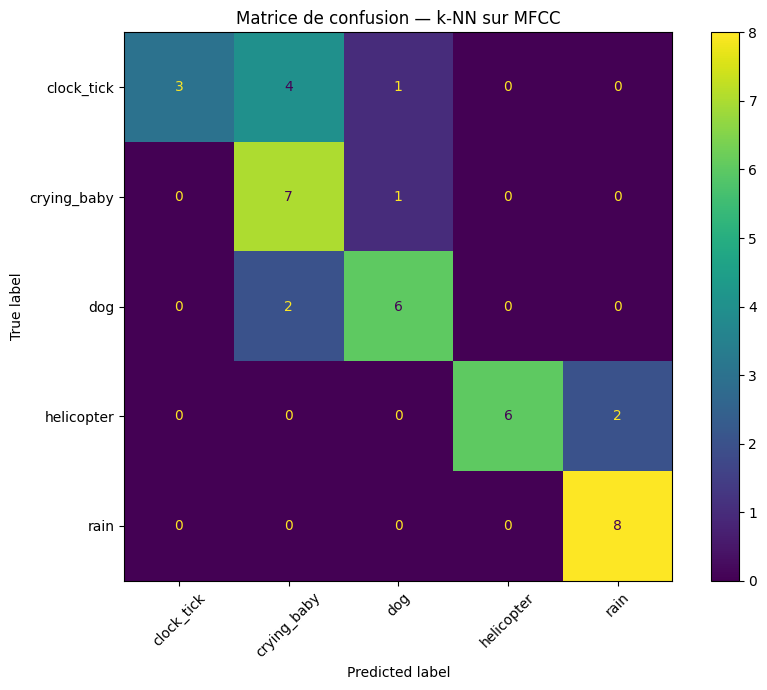

In [37]:
class_names = sorted(selected_classes)

confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Matrice de confusion — k-NN sur MFCC")
plt.tight_layout()
plt.show()

## 20. Rapport de classification

L’accuracy résume la performance globale, mais elle peut masquer les différences entre les classes.

Nous allons donc calculer pour chaque catégorie :

- la precision : parmi les prédictions d’une classe, combien sont correctes ;
- le recall : parmi les vrais exemples d’une classe, combien ont été retrouvés ;
- le F1-score : un compromis entre precision et recall ;
- le support : le nombre d’exemples disponibles dans le jeu de test.

In [39]:
report = classification_report(
    y_test,
    y_pred,
    labels=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

  clock_tick       1.00      0.38      0.55         8
 crying_baby       0.54      0.88      0.67         8
         dog       0.75      0.75      0.75         8
  helicopter       1.00      0.75      0.86         8
        rain       0.80      1.00      0.89         8

    accuracy                           0.75        40
   macro avg       0.82      0.75      0.74        40
weighted avg       0.82      0.75      0.74        40



## 21. Analyse des erreurs

Nous allons identifier précisément les fichiers mal classés.

Pour chaque erreur, nous afficherons :

- le nom du fichier ;
- la vraie catégorie ;
- la catégorie prédite ;
- le fold d’origine.

Cette analyse est importante pour comprendre les limites du modèle au-delà des métriques globales.

In [40]:
test_subset = subset[test_mask].copy()

test_subset["true_label"] = y_test
test_subset["predicted_label"] = y_pred
test_subset["correct"] = (
    test_subset["true_label"]
    == test_subset["predicted_label"]
)

errors = test_subset[
    ~test_subset["correct"]
][
    [
        "filename",
        "true_label",
        "predicted_label",
        "fold"
    ]
]

print("Nombre d'erreurs :", len(errors))

errors

Nombre d'erreurs : 10


,filename,true_label,predicted_label,fold
1652,5-177957-A-40.wav,helicopter,rain,5
1730,5-198411-C-20.wav,crying_baby,dog,5
1752,5-201194-A-38.wav,clock_tick,crying_baby,5
1771,5-205898-A-40.wav,helicopter,rain,5
1780,5-208030-A-0.wav,dog,crying_baby,5
1781,5-208624-A-38.wav,clock_tick,crying_baby,5
1787,5-209833-A-38.wav,clock_tick,crying_baby,5
1792,5-210571-A-38.wav,clock_tick,dog,5
1845,5-219342-A-38.wav,clock_tick,crying_baby,5
1999,5-9032-A-0.wav,dog,crying_baby,5


## 22. Inspection d’un exemple mal classé

Les métriques indiquent qu’une erreur existe, mais elles n’expliquent pas pourquoi.

Nous allons écouter un exemple mal classé afin de vérifier si la confusion du modèle paraît compréhensible.

In [41]:
first_error = test_subset[
    ~test_subset["correct"]
].iloc[0]

error_audio, error_sample_rate = librosa.load(
    first_error["audio_path"],
    sr=None,
    mono=True
)

print("Fichier :", first_error["filename"])
print("Vraie classe :", first_error["true_label"])
print("Classe prédite :", first_error["predicted_label"])
print("Sample rate :", error_sample_rate, "Hz")

display(
    Audio(
        error_audio,
        rate=error_sample_rate
    )
)

Fichier : 5-177957-A-40.wav
Vraie classe : helicopter
Classe prédite : rain
Sample rate : 44100 Hz


## 23. Interprétation de l’erreur

La mauvaise prédiction observée reste acoustiquement compréhensible.

Le modèle ne travaille pas avec le sens du son comme un humain. Il compare uniquement des vecteurs de caractéristiques MFCC résumés par leur moyenne et leur écart-type.

Deux sons différents peuvent donc produire des représentations proches lorsqu’ils partagent certaines propriétés :

- une énergie similaire ;
- des fréquences dominantes proches ;
- une texture sonore répétitive ;
- un bruit de fond comparable.

Cette erreur montre aussi une limite importante de notre baseline : le résumé statistique des MFCC supprime une grande partie de l’évolution temporelle du signal.

Le modèle obtient néanmoins une accuracy de 75 %, ce qui constitue une baseline utile avant d’essayer des représentations ou des modèles plus avancés.